In [2]:
!pip install kagglehub -q
import kagglehub
import pandas as pd
import numpy as np
import os

In [3]:
# Download dataset
path = kagglehub.dataset_download("rabieelkharoua/predict-online-gaming-behavior-dataset")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
data = pd.read_csv(os.path.join(path, csv_file))
data

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40029,49029,32,Male,USA,Strategy,20.619662,0,Easy,4,75,85,14,Medium
40030,49030,44,Female,Other,Simulation,13.539280,0,Hard,19,114,71,27,High
40031,49031,15,Female,USA,RPG,0.240057,1,Easy,10,176,29,1,High
40032,49032,34,Male,USA,Sports,14.017818,1,Medium,3,128,70,10,Medium


In [4]:
df = data.loc[:, ['SessionsPerWeek', 'AchievementsUnlocked', 'PlayerLevel', 'AvgSessionDurationMinutes','EngagementLevel']] 
df.to_csv("datause.csv", index=False)
df 

,SessionsPerWeek,AchievementsUnlocked,PlayerLevel,AvgSessionDurationMinutes,EngagementLevel
0,6,25,79,108,Medium
1,5,10,11,144,Medium
2,16,41,35,142,High
3,9,47,57,85,Medium
4,2,37,95,131,Medium
...,...,...,...,...,...
40029,4,14,85,75,Medium
40030,19,27,71,114,High
40031,10,1,29,176,High
40032,3,10,70,128,Medium


# Check the category distribution (is it unbalanced?)

Class count:
EngagementLevel
Medium    19374
High      10336
Low       10324
Name: count, dtype: int64

Class ratio:
EngagementLevel
Medium    0.483939
High      0.258181
Low       0.257881
Name: proportion, dtype: float64


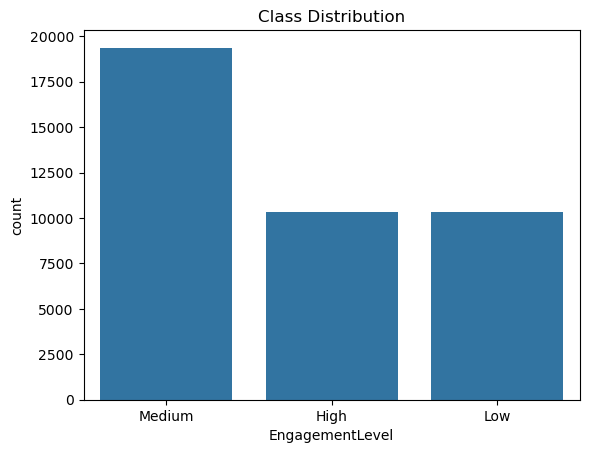

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

X = df[['SessionsPerWeek', 'AchievementsUnlocked', 'PlayerLevel', 'AvgSessionDurationMinutes']]
y = df["EngagementLevel"]

print("Class count:")
print(y.value_counts())

print("\nClass ratio:")
print(y.value_counts(normalize=True))

sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()

# Model training and evaluation (80% train, 20%test)

In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
# =========================
# Feature & Target
# =========================
X = df[['SessionsPerWeek',
           'AchievementsUnlocked', 'PlayerLevel',
           'AvgSessionDurationMinutes']]

le = LabelEncoder()
y = le.fit_transform(df["EngagementLevel"])

# =========================
# Train-test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# Pipeline (without class_weight)
# =========================
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
    ))
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="f1_macro",
)

# =========================
# Train model
# =========================
grid.fit(X_train, y_train)

# =========================
# ROC
# =========================

best_model = grid.best_estimator_
y_proba = best_model.predict_proba(X_test)

roc_auc = roc_auc_score(
    y_test,
    y_proba,
    multi_class="ovr",
    average="macro"
)

print("\n===== ROC-AUC (No class_weight) =====")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\n===== Best Parameters (No class_weight) =====")
print(grid.best_params_)
print("Best CV Score:", grid.best_score_)

# =========================
# Test evaluation
# =========================
y_pred = grid.predict(X_test)

print("\n===== Test Report (No class_weight) =====")
print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

# =========================
# Pipeline (with class_weight)
# =========================
pipe_balanced = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        solver="lbfgs",
        class_weight="balanced",
        max_iter=1000,
    ))
])

grid_balanced = GridSearchCV(
    pipe_balanced,
    param_grid,
    cv=5,
    scoring="f1_macro",
)

# =========================
# Train balanced model
# =========================
grid_balanced.fit(X_train, y_train)

# =========================
# ROC
# =========================
best_model_bal = grid_balanced.best_estimator_
y_proba_bal= best_model.predict_proba(X_test)

roc_auc_bal = roc_auc_score(
    y_test,
    y_proba_bal,
    multi_class="ovr",
    average="macro"
)

print("\n===== ROC-AUC (Balanced) =====")
print(f"ROC-AUC: {roc_auc_bal:.4f}")


print("\n===== Best Parameters (Balanced) =====")
print(grid_balanced.best_params_)
print("Best CV Score:", grid_balanced.best_score_)

# =========================
# 8. Test evaluation (balanced)
# =========================
y_pred_bal = grid_balanced.predict(X_test)

print("\n===== Test Report (Balanced) =====")
print(classification_report(
    y_test,
    y_pred_bal,
    target_names=le.classes_
))


===== ROC-AUC (No class_weight) =====
ROC-AUC: 0.9130

===== Best Parameters (No class_weight) =====
{'model__C': 0.1}
Best CV Score: 0.8179307341744074

===== Test Report (No class_weight) =====
              precision    recall  f1-score   support

        High       0.89      0.83      0.86      2067
         Low       0.79      0.69      0.74      2065
      Medium       0.80      0.88      0.84      3875

    accuracy                           0.82      8007
   macro avg       0.83      0.80      0.81      8007
weighted avg       0.82      0.82      0.82      8007


===== ROC-AUC (Balanced) =====
ROC-AUC: 0.9130

===== Best Parameters (Balanced) =====
{'model__C': 10}
Best CV Score: 0.7900983058266471

===== Test Report (Balanced) =====
              precision    recall  f1-score   support

        High       0.78      0.90      0.84      2067
         Low       0.68      0.81      0.74      2065
      Medium       0.87      0.71      0.78      3875

    accuracy                 

# Different C value vs their corresponding F1-score, Accuracy, and Log-loss for Logistic Regression

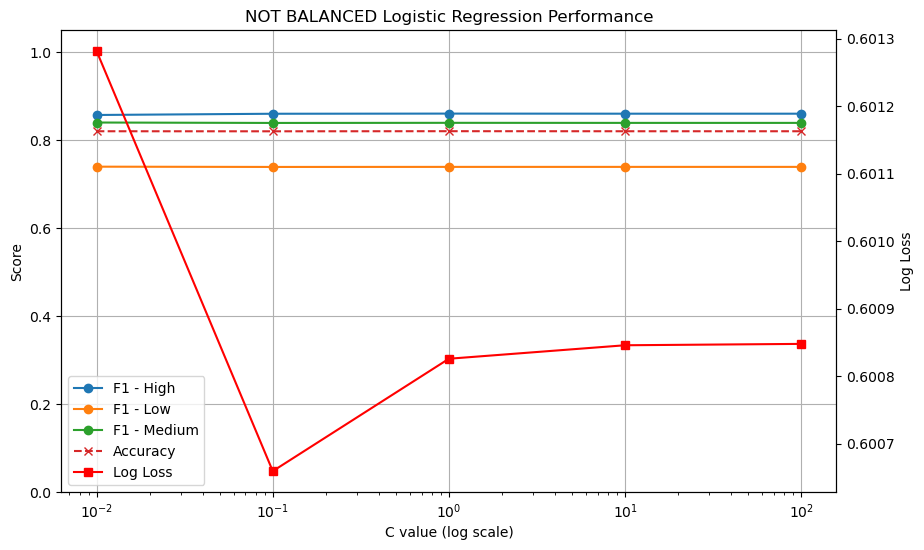

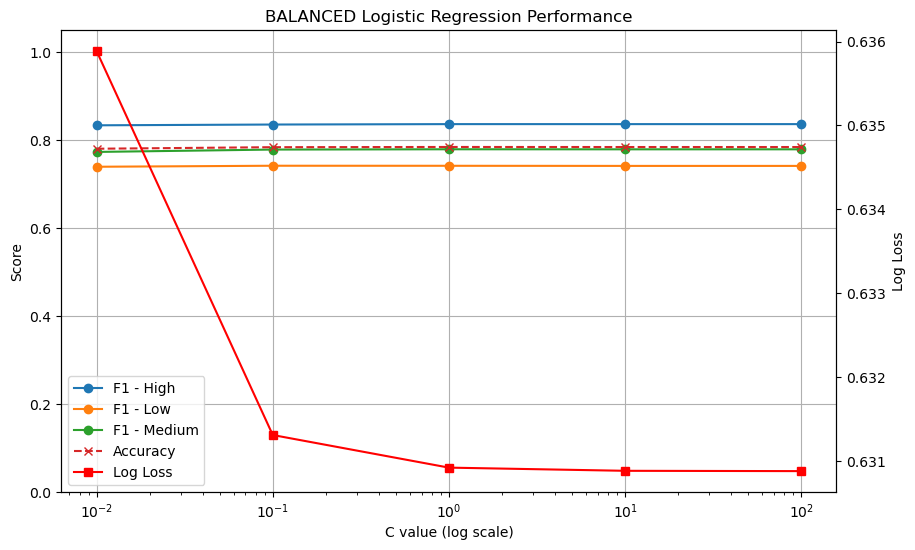

In [133]:
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, log_loss

# =========================
# Containers
# =========================
f1_nb = {name: [] for name in class_names}
acc_nb, ll_nb = [], []

f1_b = {name: [] for name in class_names}
acc_b, ll_b = [], []

# =========================
# Training loop
# =========================
for C in C_values:

    # =========================
    # Not Balanced
    # =========================
    model_nb = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=C, max_iter=1000))
    ])

    model_nb.fit(X_train, y_train)
    pred_nb = model_nb.predict(X_test)
    proba_nb = model_nb.predict_proba(X_test)

    report_nb = classification_report(y_test, pred_nb, output_dict=True)

    for i, name in enumerate(class_names):
        f1_nb[name].append(report_nb[str(i)]["f1-score"])

    acc_nb.append(accuracy_score(y_test, pred_nb))
    ll_nb.append(log_loss(y_test, proba_nb))


    # =========================
    # Balanced
    # =========================
    model_b = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=C,
            class_weight="balanced",
            max_iter=1000
        ))
    ])

    model_b.fit(X_train, y_train)
    pred_b = model_b.predict(X_test)
    proba_b = model_b.predict_proba(X_test)

    report_b = classification_report(y_test, pred_b, output_dict=True)

    for i, name in enumerate(class_names):
        f1_b[name].append(report_b[str(i)]["f1-score"])

    acc_b.append(accuracy_score(y_test, pred_b))
    ll_b.append(log_loss(y_test, proba_b))

# =========================================================
# 📊 FIGURE 1: NOT BALANCED
# =========================================================
fig1, ax1 = plt.subplots(figsize=(10,6))

for name in class_names:
    ax1.plot(C_values, f1_nb[name], marker='o', label=f'F1 - {name}')

ax1.plot(C_values, acc_nb, marker='x', linestyle='--', label='Accuracy')

ax1.set_xscale('log')
ax1.set_xlabel("C value (log scale)")
ax1.set_ylabel("Score")
ax1.set_ylim(0, 1.05)
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(C_values, ll_nb, marker='s', color='red', label='Log Loss')
ax2.set_ylabel("Log Loss")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.title("NOT BALANCED Logistic Regression Performance")
plt.show()


# =========================================================
# 📊 FIGURE 2: BALANCED
# =========================================================
fig2, ax1 = plt.subplots(figsize=(10,6))

for name in class_names:
    ax1.plot(C_values, f1_b[name], marker='o', label=f'F1 - {name}')

ax1.plot(C_values, acc_b, marker='x', linestyle='--', label='Accuracy')

ax1.set_xscale('log')
ax1.set_xlabel("C value (log scale)")
ax1.set_ylabel("Score")
ax1.set_ylim(0, 1.05)
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(C_values, ll_b, marker='s', color='red', label='Log Loss')
ax2.set_ylabel("Log Loss")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.title("BALANCED Logistic Regression Performance")
plt.show()

# Decision Boundary of Logistic Regression for User Engagement Levels

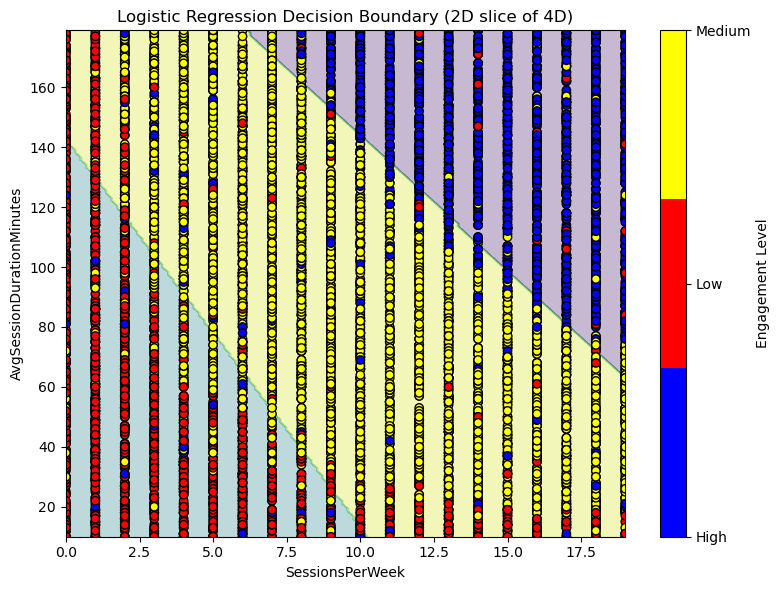

Classes: ['High' 'Low' 'Medium']
Pipeline(steps=[('scaler', StandardScaler()),
                ('lr', LogisticRegression(C=100, max_iter=1000))])


In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import ListedColormap

# =========================
# 4. FIXED VALUES (for 6D → 2D slice)
# =========================
fixed = X_train.mean()

# =========================
# 5. GRID (2 features only)
# =========================
x_min, x_max = X["SessionsPerWeek"].min(), X["SessionsPerWeek"].max()
y_min, y_max = X["AvgSessionDurationMinutes"].min(), X["AvgSessionDurationMinutes"].max()

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# =========================
# 6. BUILD FULL FEATURE GRID (MATCH TRAIN FEATURES EXACTLY)
# =========================
grid = pd.DataFrame({
    'SessionsPerWeek': xx.ravel(),
    'AchievementsUnlocked': np.repeat(fixed['AchievementsUnlocked'], xx.size),
    'PlayerLevel': np.repeat(fixed['PlayerLevel'], xx.size),
    'AvgSessionDurationMinutes': yy.ravel()
})

grid = grid[features]  # ensure correct order

# =========================
# 7. PREDICT
# =========================
Z = model.predict(grid)
Z = Z.reshape(xx.shape)

# =========================
# 8. PLOT DECISION BOUNDARY
# =========================
plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")

cmap = ListedColormap(["blue", "red", "yellow"])

plt.scatter(
    X_test["SessionsPerWeek"],
    X_test["AvgSessionDurationMinutes"],
    c=y_test,
    cmap=cmap,
    edgecolor="k"
)

plt.xlabel("SessionsPerWeek")
plt.ylabel("AvgSessionDurationMinutes")
plt.title("Logistic Regression Decision Boundary (2D slice of 4D)")

cbar = plt.colorbar(ticks=[0,1,2])
cbar.set_label("Engagement Level")
cbar.set_ticklabels(le.classes_)

plt.tight_layout()
plt.show()

# =========================
# 9. INFO
# =========================
print("Classes:", le.classes_)
print(model)

# Logistic Regression Coefficients for High / Medium / Low Engagement

Engagement Level:
0: High
1: Low
2: Medium
   SessionsPerWeek  AchievementsUnlocked  PlayerLevel  \
0         2.160075              0.170933     0.158663   
1        -2.038704             -0.239362    -0.221659   
2        -0.121371              0.068429     0.062997   

   AvgSessionDurationMinutes  
0                   1.849965  
1                  -1.553201  
2                  -0.296764  


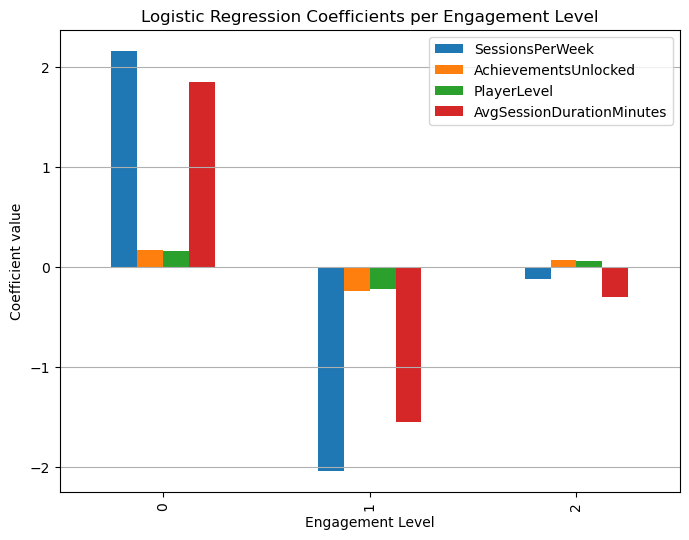

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(solver="lbfgs", max_iter=1000))
])

pipe.fit(X_train, y_train)
model = pipe.named_steps['lr']

# Get internal category code
classes = model.classes_

print("Engagement Level:")
for i, class_name in enumerate(le.classes_):
    print(f"{i}: {class_name}")

coef_df = pd.DataFrame(model.coef_, columns=X_train.columns, index=classes)
print(coef_df)

coef_df.plot(kind='bar', figsize=(8,6))
plt.title("Logistic Regression Coefficients per Engagement Level")
plt.ylabel("Coefficient value")
plt.xlabel("Engagement Level")
plt.grid(axis='y')
plt.show()

# Confusion Matrix

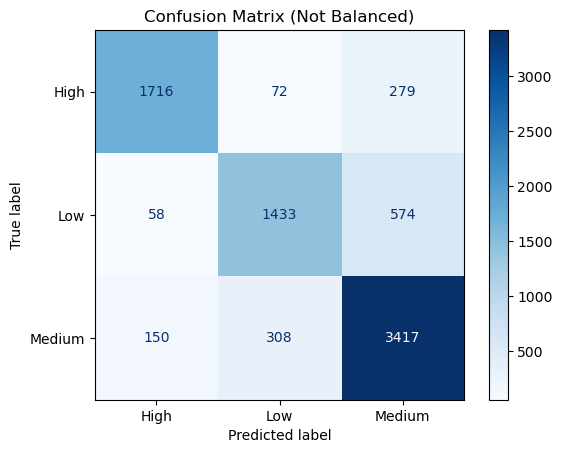

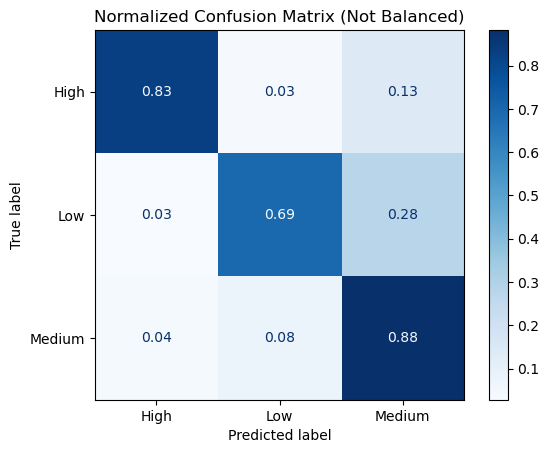

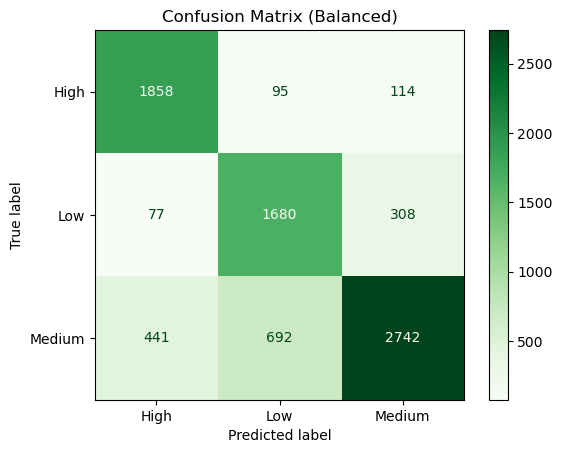

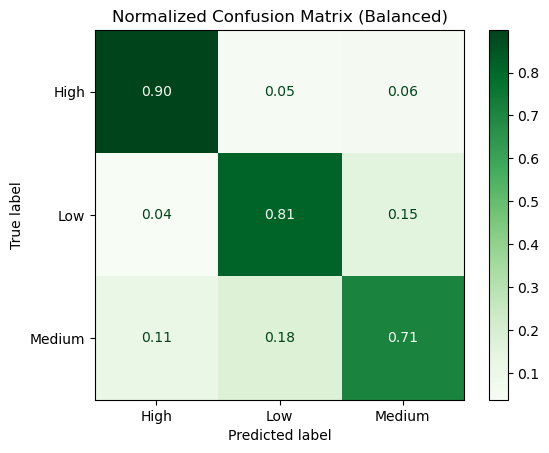

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#==========balanced==========
# 原始
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Not Balanced)")
plt.show()

# ✅ Normalized
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')

disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=le.classes_
)

disp_norm.plot(cmap="Blues", values_format=".2f")
plt.title("Normalized Confusion Matrix (Not Balanced)")
plt.show()

#==========balanced==========
# 原始
cm_bal = confusion_matrix(y_test, y_pred_bal)

disp_bal = ConfusionMatrixDisplay(
    confusion_matrix=cm_bal,
    display_labels=le.classes_
)

disp_bal.plot(cmap="Greens")
plt.title("Confusion Matrix (Balanced)")
plt.show()

# ✅ Normalized
cm_bal_norm = confusion_matrix(y_test, y_pred_bal, normalize='true')

disp_bal_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_bal_norm,
    display_labels=le.classes_
)

disp_bal_norm.plot(cmap="Greens", values_format=".2f")
plt.title("Normalized Confusion Matrix (Balanced)")
plt.show()

# Train and Test Loss Convergence of SGD Logistic Regression (80/20 Split)

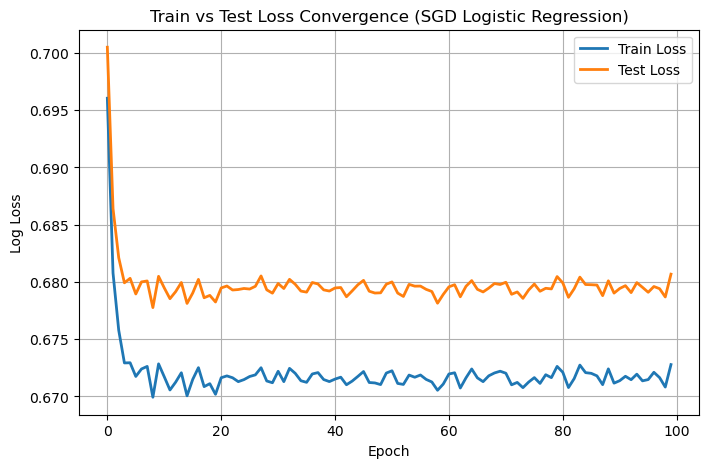

In [139]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler

# =========================
# 1. 标准化
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# 2. SGD Logistic Regression
# =========================
clf = SGDClassifier(
    loss="log_loss",
    learning_rate="constant",
    eta0=0.001,
    random_state=42
)

classes = np.unique(y_train)

train_losses = []
test_losses = []

# =========================
# 3. Training loop
# =========================
for epoch in range(100):

    # shuffle
    idx = np.random.permutation(len(X_train_scaled))
    X_batch = X_train_scaled[idx]
    y_batch = y_train[idx]

    # partial fit
    clf.partial_fit(X_batch, y_batch, classes=classes)

    # =========================
    # Train loss
    # =========================
    y_prob_train = clf.predict_proba(X_train_scaled)
    y_prob_train = np.clip(y_prob_train, 1e-10, 1 - 1e-10)
    train_loss = log_loss(y_train, y_prob_train)
    train_losses.append(train_loss)

    # =========================
    # Test loss
    # =========================
    y_prob_test = clf.predict_proba(X_test_scaled)
    y_prob_test = np.clip(y_prob_test, 1e-10, 1 - 1e-10)
    test_loss = log_loss(y_test, y_prob_test)
    test_losses.append(test_loss)

# =========================
# 4. Plot
# =========================
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss", linewidth=2)
plt.plot(test_losses, label="Test Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Train vs Test Loss Convergence (SGD Logistic Regression)")
plt.legend()
plt.grid(True)

plt.show()

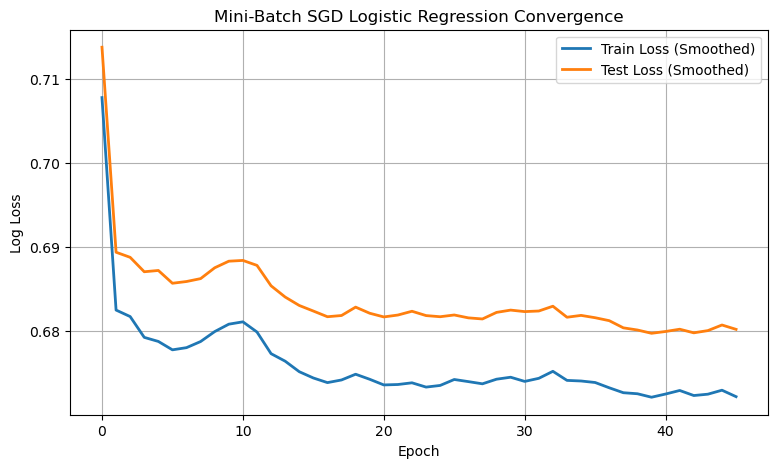

In [140]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler

# =========================
# Standardization
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# SGD Logistic Regression
# =========================
clf = SGDClassifier(
    loss="log_loss",
    learning_rate="optimal",  
    random_state=42
)

classes = np.unique(y_train)

# =========================
# params
# =========================
epochs = 50
batch_size = 32

train_losses = []
test_losses = []

# =========================
# Training loop (Mini-batch SGD)
# =========================
for epoch in range(epochs):

    # shuffle
    idx = np.random.permutation(len(X_train_scaled))
    X_train_shuffled = X_train_scaled[idx]
    y_train_shuffled = y_train[idx]

    # mini-batch training
    for i in range(0, len(X_train_scaled), batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]

        clf.partial_fit(X_batch, y_batch, classes=classes)

    # =========================
    # Train loss
    # =========================
    y_prob_train = clf.predict_proba(X_train_scaled)
    y_prob_train = np.clip(y_prob_train, 1e-10, 1 - 1e-10)
    train_loss = log_loss(y_train, y_prob_train)
    train_losses.append(train_loss)

    # =========================
    # Test loss
    # =========================
    y_prob_test = clf.predict_proba(X_test_scaled)
    y_prob_test = np.clip(y_prob_test, 1e-10, 1 - 1e-10)
    test_loss = log_loss(y_test, y_prob_test)
    test_losses.append(test_loss)

# =========================
# Smooth curve
# =========================
def smooth_curve(data, window=5):
    return np.convolve(data, np.ones(window)/window, mode='valid')

train_smooth = smooth_curve(train_losses)
test_smooth = smooth_curve(test_losses)

# =========================
# Plot (publication style)
# =========================
plt.figure(figsize=(9,5))

plt.plot(train_smooth, label="Train Loss (Smoothed)", linewidth=2)
plt.plot(test_smooth, label="Test Loss (Smoothed)", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Mini-Batch SGD Logistic Regression Convergence")
plt.legend()
plt.grid(True)

plt.show()

# FULL DATA

In [48]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# =========================
# Feature & Target
# =========================
X = dtuse[['Age', 'PlayTimeHours', 'SessionsPerWeek',
           'AchievementsUnlocked', 'PlayerLevel',
           'AvgSessionDurationMinutes']]

le = LabelEncoder()
y = le.fit_transform(dtuse["EngagementLevel"])

# =========================
# Pipeline (No class_weight)
# =========================
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
    ))
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="f1_macro",
)

# =========================
# Train on FULL DATA
# =========================
grid.fit(X, y)

print("\n===== Best Parameters (Full Data, No class_weight) =====")
print(grid.best_params_)
print("Best CV Score:", grid.best_score_)

# =========================
# In-sample evaluation
# =========================
y_pred = grid.predict(X)

print("\n--- Full Data Evaluation (NOT generalization) ---")
print(f"Accuracy: {accuracy_score(y, y_pred):.4f}")
print(classification_report(
    y,
    y_pred,
    target_names=le.classes_
))


===== Best Parameters (Full Data, No class_weight) =====
{'model__C': 10}
Best CV Score: 0.8172579109528881

--- Full Data Evaluation (NOT generalization) ---
Accuracy: 0.8239
              precision    recall  f1-score   support

        High       0.90      0.83      0.86     10336
         Low       0.80      0.70      0.75     10324
      Medium       0.80      0.89      0.84     19374

    accuracy                           0.82     40034
   macro avg       0.83      0.81      0.82     40034
weighted avg       0.83      0.82      0.82     40034



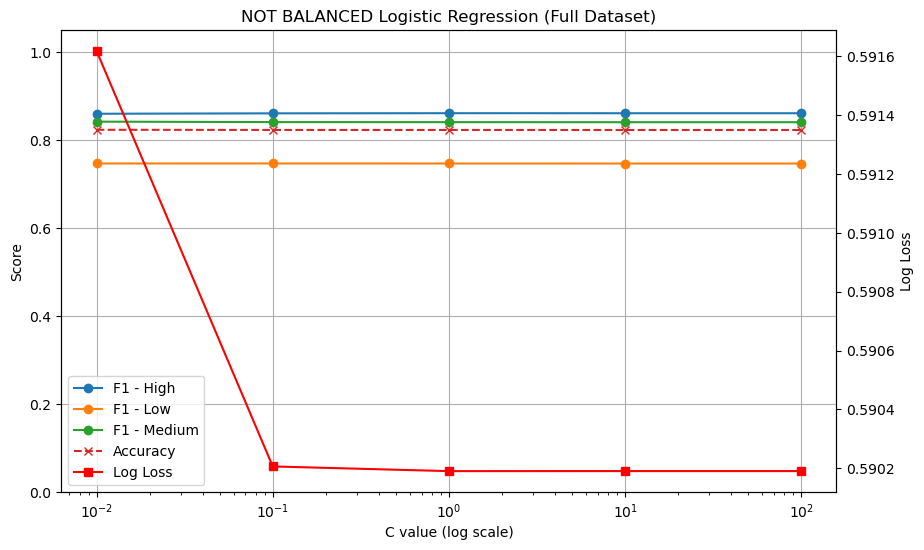

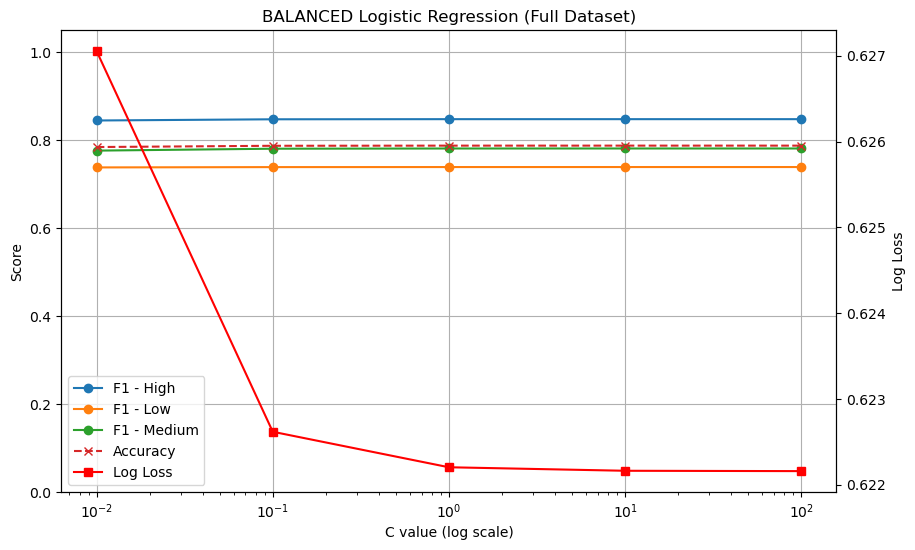

In [146]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, log_loss

# =========================
# Full dataset
# =========================
X_full = X
y_full = y

# =========================
# Containers
# =========================
f1_nb = {name: [] for name in class_names}
acc_nb, ll_nb = [], []

f1_b = {name: [] for name in class_names}
acc_b, ll_b = [], []

# =========================
# Training loop over C
# =========================
for C in C_values:

    # =========================
    # NOT BALANCED
    # =========================
    model_nb = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=C, max_iter=1000))
    ])

    model_nb.fit(X_full, y_full)
    pred_nb = model_nb.predict(X_full)
    proba_nb = model_nb.predict_proba(X_full)

    report_nb = classification_report(y_full, pred_nb, output_dict=True)

    for i, name in enumerate(class_names):
        f1_nb[name].append(report_nb[str(i)]["f1-score"])

    acc_nb.append(accuracy_score(y_full, pred_nb))
    ll_nb.append(log_loss(y_full, proba_nb))

    # =========================
    # BALANCED
    # =========================
    model_b = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=C,
            class_weight="balanced",
            max_iter=1000
        ))
    ])

    model_b.fit(X_full, y_full)
    pred_b = model_b.predict(X_full)
    proba_b = model_b.predict_proba(X_full)

    report_b = classification_report(y_full, pred_b, output_dict=True)

    for i, name in enumerate(class_names):
        f1_b[name].append(report_b[str(i)]["f1-score"])

    acc_b.append(accuracy_score(y_full, pred_b))
    ll_b.append(log_loss(y_full, proba_b))

# =========================================================
# NOT BALANCED (FULL DATA)
# =========================================================
fig1, ax1 = plt.subplots(figsize=(10,6))

for name in class_names:
    ax1.plot(C_values, f1_nb[name], marker='o', label=f'F1 - {name}')

ax1.plot(C_values, acc_nb, marker='x', linestyle='--', label='Accuracy')

ax1.set_xscale('log')
ax1.set_xlabel("C value (log scale)")
ax1.set_ylabel("Score")
ax1.set_ylim(0, 1.05)
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(C_values, ll_nb, marker='s', color='red', label='Log Loss')
ax2.set_ylabel("Log Loss")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.title("NOT BALANCED Logistic Regression (Full Dataset)")
plt.show()


# =========================================================
# BALANCED (FULL DATA)
# =========================================================
fig2, ax1 = plt.subplots(figsize=(10,6))

for name in class_names:
    ax1.plot(C_values, f1_b[name], marker='o', label=f'F1 - {name}')

ax1.plot(C_values, acc_b, marker='x', linestyle='--', label='Accuracy')

ax1.set_xscale('log')
ax1.set_xlabel("C value (log scale)")
ax1.set_ylabel("Score")
ax1.set_ylim(0, 1.05)
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(C_values, ll_b, marker='s', color='red', label='Log Loss')
ax2.set_ylabel("Log Loss")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.title("BALANCED Logistic Regression (Full Dataset)")
plt.show()

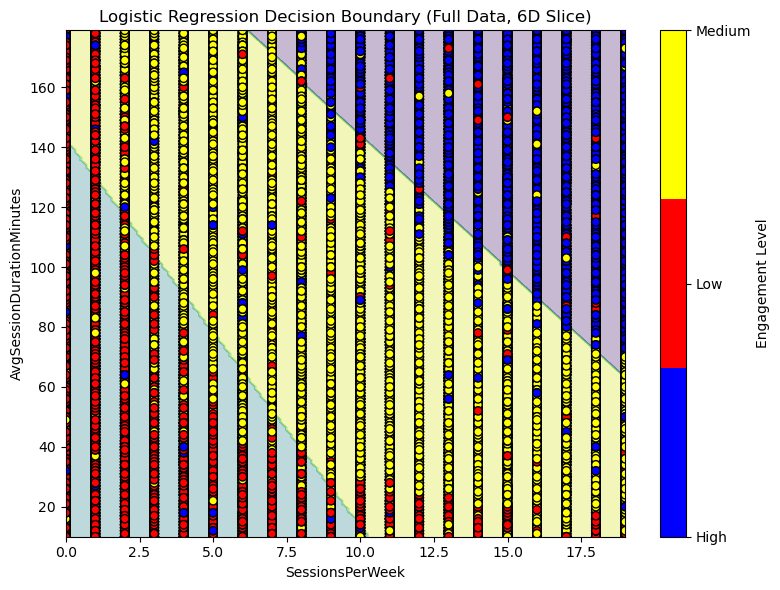

Pipeline(steps=[('scaler', StandardScaler()),
                ('lr', LogisticRegression(max_iter=1000))])
Classes: ['High' 'Low' 'Medium']


In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import ListedColormap

# =========================
# Features
# =========================
features = [
    'Age',
    'PlayTimeHours',
    'SessionsPerWeek',
    'AchievementsUnlocked',
    'PlayerLevel',
    'AvgSessionDurationMinutes'
]

X = df[features].copy()
y_raw = df["EngagementLevel"].copy()

# encode labels
le = LabelEncoder()
y = le.fit_transform(y_raw)

# =========================
# numeric
# =========================
X = X.apply(pd.to_numeric, errors='coerce')

# =========================
# model (FULL DATA)
# =========================
model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000))
])

model.fit(X, y)   # FULL DATA TRAINING

# =========================
# fixed values
# =========================
fixed = X.mean()

# =========================
# grid (2D slice)
# =========================
x_min, x_max = X["SessionsPerWeek"].min(), X["SessionsPerWeek"].max()
y_min, y_max = X["AvgSessionDurationMinutes"].min(), X["AvgSessionDurationMinutes"].max()

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# =========================
# build 6D grid
# =========================
grid_df = pd.DataFrame({
    "Age": fixed["Age"],
    "PlayTimeHours": fixed["PlayTimeHours"],
    "SessionsPerWeek": xx.ravel(),
    "AchievementsUnlocked": fixed["AchievementsUnlocked"],
    "PlayerLevel": fixed["PlayerLevel"],
    "AvgSessionDurationMinutes": yy.ravel()
})

grid_df = grid_df[features]

# =========================
# predict
# =========================
Z = model.predict(grid_df)
Z = Z.reshape(xx.shape)

# =========================
# plot
# =========================
plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")

cmap = ListedColormap(["blue", "red", "yellow"])

# FULL DATA scatter
plt.scatter(
    X["SessionsPerWeek"],
    X["AvgSessionDurationMinutes"],
    c=y,
    cmap=cmap,
    edgecolor="k"
)

plt.xlabel("SessionsPerWeek")
plt.ylabel("AvgSessionDurationMinutes")
plt.title("Logistic Regression Decision Boundary (Full Data, 6D Slice)")

# colorbar with labels
cbar = plt.colorbar(ticks=[0, 1, 2])
cbar.set_label("Engagement Level")
cbar.set_ticklabels(le.classes_)

plt.tight_layout()
plt.show()

# =========================
# output
# =========================
print(model)
print("Classes:", le.classes_)

Engagement Level: ['High' 'Low' 'Medium']
             Age  PlayTimeHours  SessionsPerWeek  AchievementsUnlocked  \
High   -0.025847       0.016136         2.137181              0.165900   
Low     0.009490       0.001411        -2.031151             -0.238249   
Medium  0.016357      -0.017547        -0.106030              0.072349   

        PlayerLevel  AvgSessionDurationMinutes  
High       0.164799                   1.831751  
Low       -0.228267                  -1.549457  
Medium     0.063468                  -0.282294  


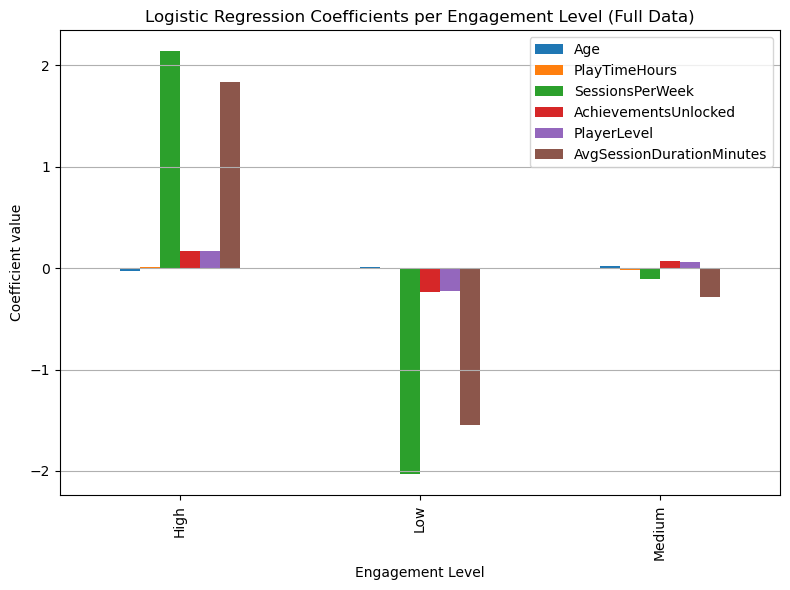

In [54]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# ===== encode labels =====
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)   # Use original label

# ===== model =====
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(solver="lbfgs", max_iter=1000))
])

# FULL DATA
pipe.fit(X, y_encoded)

model = pipe.named_steps['lr']

# ===== Replace 0/1/2 with the category name =====
class_names = le.classes_

print("Engagement Level:", class_names)

# ===== coef dataframe =====
coef_df = pd.DataFrame(
    model.coef_,
    columns=X.columns,
    index=class_names   # name
)

print(coef_df)

# ===== plot =====
coef_df.plot(kind='bar', figsize=(8,6))

plt.title("Logistic Regression Coefficients per Engagement Level (Full Data)")
plt.ylabel("Coefficient value")
plt.xlabel("Engagement Level")
plt.grid(axis='y')

plt.tight_layout()
plt.show()

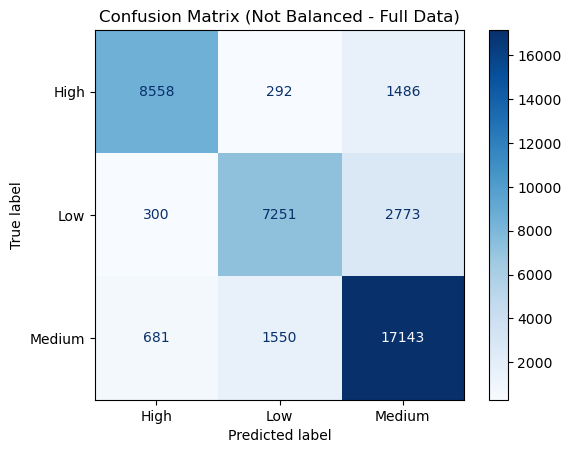

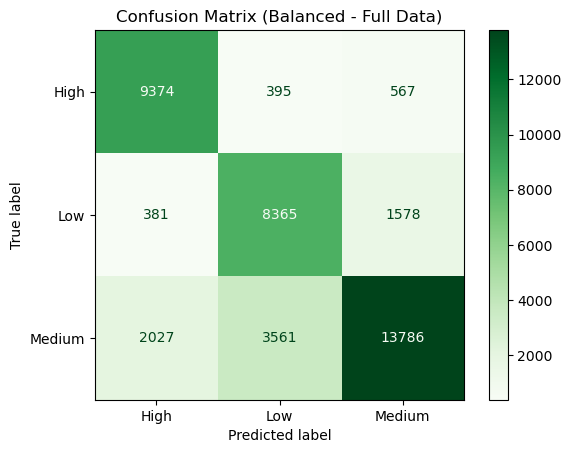

In [145]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# =========================
# Full dataset
# =========================
X_full = X
y_full = y

# =========================================================
# NOT BALANCED MODEL
# =========================================================
model_nb = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

model_nb.fit(X_full, y_full)
y_pred_nb = model_nb.predict(X_full)

cm_nb = confusion_matrix(y_full, y_pred_nb)

disp_nb = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=class_names
)

disp_nb.plot(cmap="Blues")
plt.title("Confusion Matrix (Not Balanced - Full Data)")
plt.show()


# =========================================================
# BALANCED MODEL
# =========================================================
model_b = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

model_b.fit(X_full, y_full)
y_pred_b = model_b.predict(X_full)

cm_b = confusion_matrix(y_full, y_pred_b)

disp_b = ConfusionMatrixDisplay(
    confusion_matrix=cm_b,
    display_labels=class_names
)

disp_b.plot(cmap="Greens")
plt.title("Confusion Matrix (Balanced - Full Data)")
plt.show()

# Training Loss Convergence of SGD Logistic Regression (Full Dataset)

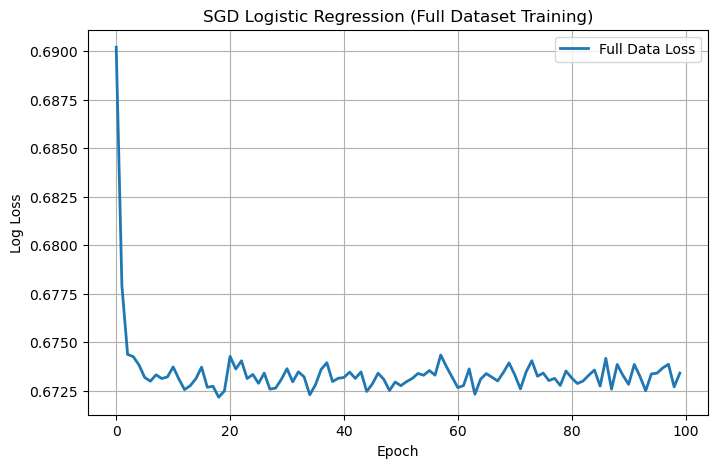

In [143]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler

# =========================
# Standardization (full data)
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_full = y

# =========================
# SGD Logistic Regression
# =========================
clf = SGDClassifier(
    loss="log_loss",
    learning_rate="constant",
    eta0=0.001,
    random_state=42
)

classes = np.unique(y_full)

train_losses = []

# =========================
# Training loop
# =========================
for epoch in range(100):

    # shuffle full dataset
    idx = np.random.permutation(len(X_scaled))
    X_shuffled = X_scaled[idx]
    y_shuffled = y_full[idx]

    # mini-batch SGD
    batch_size = 32

    for i in range(0, len(X_scaled), batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        clf.partial_fit(X_batch, y_batch, classes=classes)

    # =========================
    # FULL DATA LOSS (no split)
    # =========================
    y_prob = clf.predict_proba(X_scaled)
    y_prob = np.clip(y_prob, 1e-10, 1 - 1e-10)

    loss = log_loss(y_full, y_prob)
    train_losses.append(loss)

# =========================
# Plot
# =========================
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Full Data Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("SGD Logistic Regression (Full Dataset Training)")
plt.legend()
plt.grid(True)

plt.show()

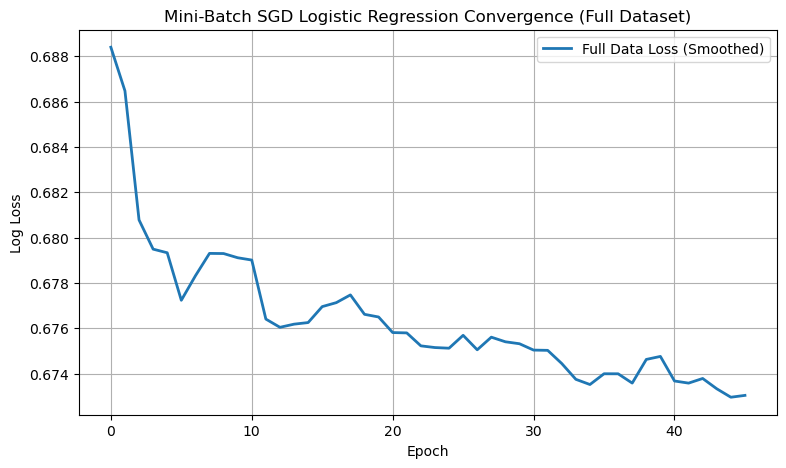

In [142]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler

# =========================
# 1. Standardization（Full data）
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_full = y

# =========================
# SGD Logistic Regression
# =========================
clf = SGDClassifier(
    loss="log_loss",
    learning_rate="optimal",
    random_state=42
)

classes = np.unique(y_full)

# =========================
# params
# =========================
epochs = 50
batch_size = 32

losses = []

# =========================
# Training loop (Mini-batch SGD)
# =========================
for epoch in range(epochs):

    # shuffle full dataset
    idx = np.random.permutation(len(X_scaled))
    X_shuffled = X_scaled[idx]
    y_shuffled = y_full[idx]

    # mini-batch training
    for i in range(0, len(X_scaled), batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        clf.partial_fit(X_batch, y_batch, classes=classes)

    # =========================
    # Full dataset loss (no split)
    # =========================
    y_prob = clf.predict_proba(X_scaled)
    y_prob = np.clip(y_prob, 1e-10, 1 - 1e-10)

    loss = log_loss(y_full, y_prob)
    losses.append(loss)

# =========================
# Smooth curve
# =========================
def smooth_curve(data, window=5):
    return np.convolve(data, np.ones(window)/window, mode='valid')

loss_smooth = smooth_curve(losses)

# =========================
# Plot
# =========================
plt.figure(figsize=(9,5))

plt.plot(loss_smooth, label="Full Data Loss (Smoothed)", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Mini-Batch SGD Logistic Regression Convergence (Full Dataset)")
plt.legend()
plt.grid(True)

plt.show()